# Boo Who? · Phase 2: Classification

This notebook trains and compares classifiers, picks the best one for the predictions file, and builds the **Oracle**: the small neural networks that run inside the game.

**Inputs:** `../data/clean/` from Phase 1
**Outputs:** `../submission.csv`, `../web/data/oracle_model.json`, `../web/data/monsters.json`, figures in `../reports/figures/`

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

CLEAN = Path('../data/clean'); FIGS = Path('../reports/figures'); WEB = Path('../web/data')
WEB.mkdir(parents=True, exist_ok=True)
prep = json.loads((CLEAN / 'preprocessing.json').read_text())
NUM, COLORS, CLASSES, FEATURES = prep['numeric'], prep['colors'], prep['classes'], prep['features']
CLASS_COLOR = dict(zip(CLASSES, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))
BLUE, INK, MUTED, GRID = '#2a78d6', '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#8a8984', 'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'axes.titleweight': 'bold', 'axes.titlesize': 11})
SEED = 42

## 1. Load data and split

In [2]:
train = pd.read_csv(CLEAN / 'train_scaled.csv'); raw = pd.read_csv(CLEAN / 'train_clean.csv')
comp = pd.read_csv(CLEAN / 'comp_scaled.csv')
cls_to_int = {c: i for i, c in enumerate(CLASSES)}          # labels as numbers, fixed class order
X, y = train[FEATURES].values, train['class'].map(cls_to_int).values

idx_tr, idx_te = train_test_split(np.arange(len(train)), test_size=0.2, stratify=y, random_state=SEED)
Xtr, Xte, ytr, yte = X[idx_tr], X[idx_te], y[idx_tr], y[idx_te]
print(f'train split: {len(idx_tr):,} monsters | test split: {len(idx_te):,} monsters (never used for training or tuning)')
pd.DataFrame({'train %': np.bincount(ytr) / len(ytr) * 100, 'test %': np.bincount(yte) / len(yte) * 100}, index=CLASSES).round(1)

train split: 29,997 monsters | test split: 7,500 monsters (never used for training or tuning)


,train %,test %
Zombie,39.9,39.9
Witch,19.8,19.8
Ghost,15.1,15.1
Vampire,15.1,15.1
Mummy,10.1,10.1


## 2. Baseline

In [3]:
base = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
pb = base.predict(Xte)
print(f'Always guessing Zombie: accuracy {accuracy_score(yte, pb):.3f}, macro-F1 {f1_score(yte, pb, average="macro"):.3f}')

Always guessing Zombie: accuracy 0.399, macro-F1 0.114


Any real model has to beat about 40% accuracy and a macro-F1 of about 0.11 by a wide margin.

## 3. Compare models (5-fold cross-validation on the train split)

In [4]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Logistic Regression (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=2, random_state=SEED),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, n_jobs=2, verbose=-1, random_state=SEED),
    'LightGBM (balanced)': LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced', n_jobs=2, verbose=-1, random_state=SEED),
    'Neural network (64-32)': MLPClassifier((64, 32), max_iter=500, early_stopping=True, random_state=SEED),
}
rows = []
for name, m in models.items():
    t0 = time.time()
    r = cross_validate(m, Xtr, ytr, cv=cv, scoring={'f1': 'f1_macro', 'acc': 'accuracy'})
    rows.append({'model': name, 'macro-F1': r['test_f1'].mean(), 'F1 std': r['test_f1'].std(),
                 'accuracy': r['test_acc'].mean(), 'seconds': time.time() - t0})
cv_table = pd.DataFrame(rows).sort_values('macro-F1', ascending=False).set_index('model')
cv_table.round(4)

,macro-F1,F1 std,accuracy,seconds
model,,,,
LightGBM (balanced),0.8568,0.0049,0.8876,13.2969
Random Forest,0.8544,0.0036,0.8937,39.0281
LightGBM,0.8536,0.0044,0.8928,14.6500
Neural network (64-32),0.8529,0.0030,0.8929,15.1482
Logistic Regression (balanced),0.8284,0.0043,0.8611,2.3756
Logistic Regression,0.8260,0.0036,0.8718,2.3061


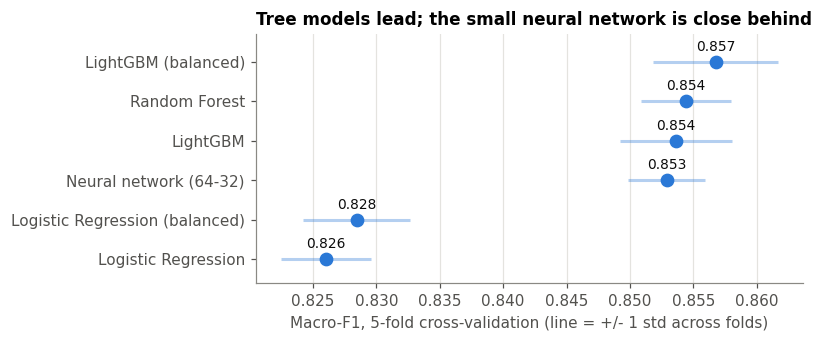

In [5]:
t = cv_table.sort_values('macro-F1')
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ypos = np.arange(len(t))
ax.hlines(ypos, t['macro-F1'] - t['F1 std'], t['macro-F1'] + t['F1 std'], color=BLUE, linewidth=2, alpha=0.35)
ax.plot(t['macro-F1'], ypos, 'o', color=BLUE, markersize=8)
for yv, v in zip(ypos, t['macro-F1']):
    ax.text(v, yv + 0.28, f'{v:.3f}', ha='center', fontsize=9, color=INK)
ax.set_yticks(ypos, t.index); ax.set_ylim(-0.6, len(t) - 0.3)
ax.set_title('Tree models lead; the small neural network is close behind', loc='left')
ax.set_xlabel('Macro-F1, 5-fold cross-validation (line = +/- 1 std across folds)')
ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'model_comparison.png', bbox_inches='tight'); plt.show()

## 4. Tune the gradient boosting model

In [6]:
grid = [dict(num_leaves=nl, learning_rate=lr, n_estimators=ne, min_child_samples=mcs)
        for nl in (15, 31) for lr, ne in ((0.03, 600), (0.05, 300)) for mcs in (20, 60)]
cv3 = StratifiedKFold(3, shuffle=True, random_state=SEED)
tune = []
for g in grid:
    m = LGBMClassifier(**g, class_weight='balanced', n_jobs=2, verbose=-1, random_state=SEED)
    s = cross_validate(m, Xtr, ytr, cv=cv3, scoring='f1_macro')['test_score'].mean()
    tune.append({**g, 'macro-F1': s})
tune = pd.DataFrame(tune).sort_values('macro-F1', ascending=False)
best_params = tune.iloc[0].drop('macro-F1').to_dict()
best_params = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in best_params.items()}
print('best settings:', best_params)
tune.round(4).head(8)

best settings: {'num_leaves': 15, 'learning_rate': 0.03, 'n_estimators': 600, 'min_child_samples': 20}


,num_leaves,learning_rate,n_estimators,min_child_samples,macro-F1
0,15,0.03,600,20,0.8594
2,15,0.05,300,20,0.8590
3,15,0.05,300,60,0.8579
6,31,0.05,300,20,0.8570
1,15,0.03,600,60,0.8561
4,31,0.03,600,20,0.8548
7,31,0.05,300,60,0.8548
5,31,0.03,600,60,0.8545


## 5. Pick the final model and test it once

In [7]:
candidates = {
    'LightGBM (tuned)': LGBMClassifier(**best_params, class_weight='balanced', n_jobs=2, verbose=-1, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=2, random_state=SEED),
}
cand_scores = {n: cross_validate(m, Xtr, ytr, cv=cv, scoring='f1_macro')['test_score'].mean() for n, m in candidates.items()}
final_name = max(cand_scores, key=cand_scores.get)
print({k: round(v, 4) for k, v in cand_scores.items()}, '-> final model:', final_name)

final = candidates[final_name].fit(Xtr, ytr)
pred = final.predict(Xte)
test_acc, test_f1 = accuracy_score(yte, pred), f1_score(yte, pred, average='macro')
print(f'TEST SET: accuracy {test_acc:.4f} | macro-F1 {test_f1:.4f}')
print(classification_report(yte, pred, target_names=CLASSES, digits=3))

{'LightGBM (tuned)': np.float64(0.8575), 'Random Forest': np.float64(0.8544)} -> final model: LightGBM (tuned)


TEST SET: accuracy 0.8885 | macro-F1 0.8596
              precision    recall  f1-score   support

      Zombie      0.980     0.915     0.947      2991
       Witch      0.864     0.828     0.846      1487
       Ghost      0.950     0.943     0.946      1134
     Vampire      0.894     0.964     0.927      1133
       Mummy      0.571     0.707     0.632       755

    accuracy                          0.889      7500
   macro avg      0.852     0.871     0.860      7500
weighted avg      0.898     0.889     0.892      7500



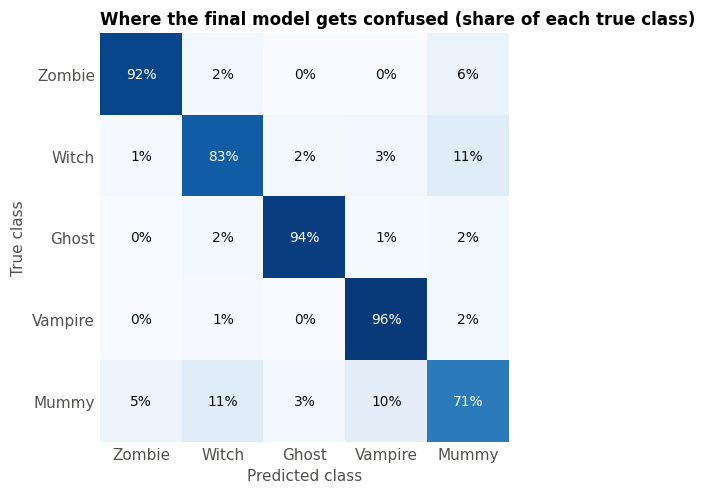

In [8]:
cm = confusion_matrix(yte, pred, normalize='true') * 100
fig, ax = plt.subplots(figsize=(6, 4.6))
ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(5), CLASSES); ax.set_yticks(range(5), CLASSES)
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm[i, j]:.0f}%', ha='center', va='center', fontsize=9, color='white' if cm[i, j] > 55 else INK)
ax.set_title('Where the final model gets confused (share of each true class)', loc='left')
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout(); plt.savefig(FIGS / 'confusion_matrix.png', bbox_inches='tight'); plt.show()

## 6. Which clues matter most? (sets the order clues appear in the game)

Clue order in the game: hair -> aura -> color -> height -> rot -> blood


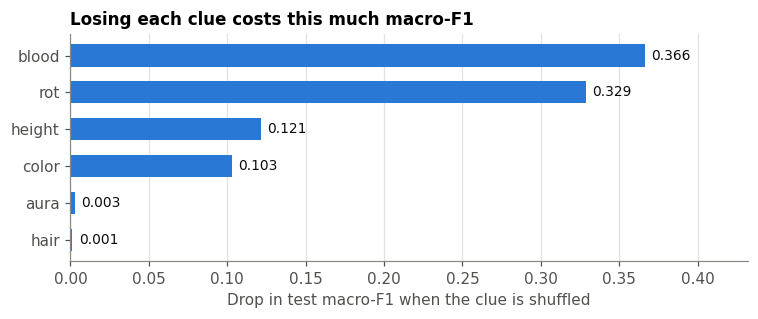

In [9]:
CLUES = {'height': ['height'], 'hair': ['hairLength'], 'color': [f'color_{c}' for c in COLORS],
         'aura': ['aura'], 'blood': ['bloodCoverage'], 'rot': ['rottingFleshPct']}
rng = np.random.default_rng(SEED)
col_idx = {f: i for i, f in enumerate(FEATURES)}
imp = {}
for clue, cols in CLUES.items():
    drops = []
    for _ in range(5):
        Xp = Xte.copy(); perm = rng.permutation(len(Xp))
        for c in cols: Xp[:, col_idx[c]] = Xte[perm, col_idx[c]]     # shuffle the whole clue together
        drops.append(test_f1 - f1_score(yte, final.predict(Xp), average='macro'))
    imp[clue] = np.mean(drops)
imp = pd.Series(imp).sort_values()
CLUE_ORDER = list(imp.index)            # least useful first: the game reveals clues in this order
print('Clue order in the game:', ' -> '.join(CLUE_ORDER))

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
for b, v in zip(bars, imp.values):
    ax.text(v + 0.004, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center', fontsize=9, color=INK)
ax.set_title('Losing each clue costs this much macro-F1', loc='left')
ax.set_xlabel('Drop in test macro-F1 when the clue is shuffled'); ax.set_xlim(0, imp.max() * 1.18)
ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'clue_importance.png', bbox_inches='tight'); plt.show()

## 7. The Oracle: one small network per clue stage

In the game, clues appear one at a time, so the Oracle must predict with only some features. We train one small neural network per stage: stage 1 sees only the first clue, stage 6 sees all of them. Neural networks are used because their weights are small and easy to run in the browser. The Oracle is trained on the **train split only**, so the test-split monsters stay unseen and can be used as the game's monsters.

In [10]:
oracle_stages, stage_rows = [], []
prior = np.bincount(ytr, minlength=5) / len(ytr)
stage_rows.append({'clues shown': 0, 'clues': '(none)', 'accuracy': accuracy_score(yte, np.zeros_like(yte)),
                   'macro-F1': f1_score(yte, np.zeros_like(yte), average='macro')})
for k in range(1, len(CLUE_ORDER) + 1):
    feats = [f for clue in CLUE_ORDER[:k] for f in CLUES[clue]]
    cols = [col_idx[f] for f in feats]
    mlp = MLPClassifier((32, 16), max_iter=500, early_stopping=True, random_state=SEED).fit(Xtr[:, cols], ytr)
    p = mlp.predict(Xte[:, cols])
    stage_rows.append({'clues shown': k, 'clues': ', '.join(CLUE_ORDER[:k]), 'accuracy': accuracy_score(yte, p),
                       'macro-F1': f1_score(yte, p, average='macro')})
    oracle_stages.append({'features': feats, 'mlp': mlp, 'cols': cols})
stage_table = pd.DataFrame(stage_rows).set_index('clues shown')
stage_table.round(3)

,clues,accuracy,macro-F1
clues shown,,,
0,(none),0.399,0.114
1,hair,0.399,0.150
2,"hair, aura",0.453,0.273
3,"hair, aura, color",0.530,0.403
4,"hair, aura, color, height",0.602,0.500
5,"hair, aura, color, height, rot",0.793,0.724
6,"hair, aura, color, height, rot, blood",0.891,0.849


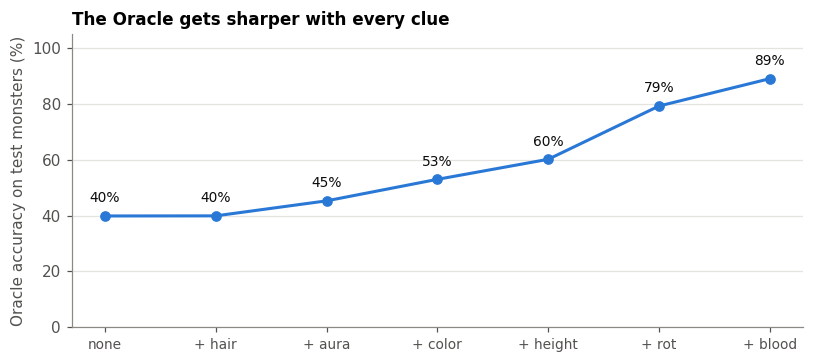

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(stage_table.index, stage_table['accuracy'] * 100, color=BLUE, linewidth=2, marker='o', markersize=6)
for k, v in (stage_table['accuracy'] * 100).items():
    ax.annotate(f'{v:.0f}%', (k, v), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color=INK)
ax.set_xticks(stage_table.index, ['none'] + [f'+ {c}' for c in CLUE_ORDER], fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel('Oracle accuracy on test monsters (%)')
ax.set_title('The Oracle gets sharper with every clue', loc='left')
ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'oracle_by_clues.png', bbox_inches='tight'); plt.show()

## 8. Are the Oracle's confidence numbers honest?

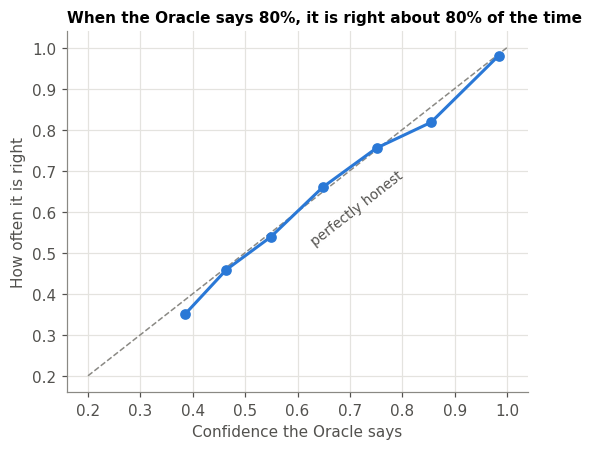

,monsters,said,right
bin,,,
"(0.2, 0.4]",20,0.385,0.350
"(0.4, 0.5]",242,0.464,0.459
"(0.5, 0.6]",442,0.549,0.538
"(0.6, 0.7]",420,0.648,0.660
"(0.7, 0.8]",482,0.751,0.755
"(0.8, 0.9]",587,0.855,0.818
"(0.9, 1.0]",5307,0.984,0.980


In [12]:
full = oracle_stages[-1]
proba = full['mlp'].predict_proba(Xte[:, full['cols']])
conf, hit = proba.max(1), proba.argmax(1) == yte
bins = pd.cut(conf, [0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
calib = pd.DataFrame({'bin': bins, 'conf': conf, 'hit': hit}).groupby('bin', observed=True).agg(
    monsters=('hit', 'size'), said=('conf', 'mean'), right=('hit', 'mean'))
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot([0.2, 1], [0.2, 1], color='#8a8984', linewidth=1, linestyle='--')
ax.plot(calib['said'], calib['right'], color=BLUE, linewidth=2, marker='o', markersize=6)
ax.text(0.62, 0.52, 'perfectly honest', color=MUTED, fontsize=9, rotation=38)
ax.set_xlabel('Confidence the Oracle says'); ax.set_ylabel('How often it is right')
ax.set_title('When the Oracle says 80%, it is right about 80% of the time', loc='left', fontsize=10)
ax.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'oracle_calibration.png', bbox_inches='tight'); plt.show()
calib.round(3)

## 9. Predictions for the competition file

In [13]:
submit_model = candidates[final_name].fit(X, y)          # refit on ALL labeled monsters
comp_pred = submit_model.predict(comp[FEATURES].values)
sample = pd.read_csv('../data/sample_sub.csv')
submission = pd.DataFrame({'id': comp['id'], 'class': [CLASSES[i] for i in comp_pred]})
assert list(submission.columns) == list(sample.columns) and submission['id'].equals(sample['id'])
submission.to_csv('../submission.csv', index=False)
print('submission.csv saved:', submission.shape)
submission['class'].value_counts(normalize=True).reindex(CLASSES).round(3)

submission.csv saved: (12503, 2)


class
Zombie     0.373
Witch      0.186
Ghost      0.153
Vampire    0.161
Mummy      0.127
Name: proportion, dtype: float64

## 10. Export for the game

In [14]:
def layers(mlp):
    return [{'W': np.round(W, 6).tolist(), 'b': np.round(b, 6).tolist()} for W, b in zip(mlp.coefs_, mlp.intercepts_)]

oracle = {
    'classes': CLASSES, 'numeric': NUM, 'colors': COLORS, 'scaler': prep['scaler'], 'train_range': prep['train_range'],
    'clue_order': CLUE_ORDER, 'clue_features': CLUES, 'prior': np.round(prior, 6).tolist(),
    'stages': [{'clues': CLUE_ORDER[:i + 1], 'features': s['features'], 'layers': layers(s['mlp'])} for i, s in enumerate(oracle_stages)],
    'stage_accuracy': [round(float(v), 4) for v in stage_table['accuracy']],
}
(WEB / 'oracle_model.json').write_text(json.dumps(oracle))

# The game's monsters: the TEST split, because those have true labels the game can grade,
# and the Oracle has never seen them. Monsters the full Oracle gets wrong become tricksters.
full_pred = full['mlp'].predict(Xte[:, full['cols']])
pool = raw.iloc[idx_te][['id', 'class'] + NUM].copy()
pool['color'] = [COLORS[int(np.argmax(r))] for r in raw.iloc[idx_te][[f'color_{c}' for c in COLORS]].values]
pool['trickster'] = (full_pred != yte).astype(int)
pool[NUM] = pool[NUM].round(6)
(WEB / 'monsters.json').write_text(pool.to_json(orient='records'))
# a small file for the JavaScript check below
check = pool.head(1000).drop(columns=['trickster']).to_dict(orient='records')
# expected answers from the exact values written to monsters.json (same clip + scale as the browser)
chk = pool.head(1000).copy()
Xc = np.column_stack([((chk[c].clip(prep['train_range'][c]['min'], prep['train_range'][c]['max']) - prep['scaler'][c]['mean']) / prep['scaler'][c]['std']) if c in NUM
                      else (chk['color'] == c.replace('color_', '')).astype(float) for c in FEATURES])
expected = [[s['mlp'].predict_proba(Xc[i:i + 1, s['cols']])[0].tolist() for s in oracle_stages] for i in range(1000)]
Path('parity_check.json').write_text(json.dumps({'monsters': check, 'expected': expected}))
print('oracle_model.json:', round((WEB / 'oracle_model.json').stat().st_size / 1024), 'KB | monsters.json:',
      len(pool), 'monsters,', int(pool.trickster.sum()), 'tricksters')

oracle_model.json: 51 KB | monsters.json: 7500 monsters, 821 tricksters


## 11. Does the browser Oracle give the same answers as Python?

In [15]:
import subprocess
out = subprocess.run(['node', '../web/tests/parity_check.mjs'], capture_output=True, text=True)
print(out.stdout or out.stderr)

Compared 6000 predictions (1,000 monsters x 6 stages).
Same top class as Python: 6000 of 6000
Largest probability difference: 3.29e-6
PASS: the browser Oracle matches Python.

